In [ ]:
%pip install tensorflow keras scikit-learn opencv-python pillow numpy matplotlib seaborn kagglehub

Using pip 26.1.1 from c:\Users\Windows\Documents\GitHub\BSc-Thesis\.venv\Lib\site-packages\pip (python 3.13)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import os, random, itertools
import numpy as np
import cv2
import tempfile
from PIL import Image, ImageChops, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv2D,
                                     MaxPool2D, Input, concatenate)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
IMAGE_SIZE = (128, 128)
ELA_QUALITY = 85
BATCH_SIZE  = 32
EPOCHS      = 20
SEED        = 42

In [ ]:
path      = kagglehub.dataset_download('divg07/casia-20-image-tampering-detection-dataset')
DATA_ROOT = Path(path) / 'CASIA2'
AU_DIR    = DATA_ROOT / 'Au'
TP_DIR    = DATA_ROOT / 'Tp'

au_paths = sorted(p for p in AU_DIR.iterdir() if p.suffix.lower() in IMG_EXTS)
tp_paths = sorted(p for p in TP_DIR.iterdir() if p.suffix.lower() in IMG_EXTS)

def get_tp_label(p: Path) -> int:
    parts = p.stem.split('_')
    if len(parts) >= 3 and parts[-3] == parts[-2]:
        return 1  # copy-move
    return 2       # splicing

all_paths  = au_paths + tp_paths
all_labels = [0] * len(au_paths) + [get_tp_label(p) for p in tp_paths]

counts = {c: all_labels.count(c) for c in range(3)}
print(f"Authentic={counts[0]}  Copy-Move={counts[1]}  Splicing={counts[2]}  Total={len(all_paths)}")

Authentic=7491  Copy-Move=3299  Splicing=1824  Total=12614


In [12]:
def convert_to_ela(path, quality=ELA_QUALITY):
    tmp_dir = tempfile.gettempdir()
    tmp = os.path.join(tmp_dir, '_ela_tmp.jpg')
    
    img = Image.open(path).convert('RGB')
    img.save(tmp, 'JPEG', quality=quality)
    tmp_img = Image.open(tmp)
    ela  = ImageChops.difference(img, tmp_img)
    extr = ela.getextrema()
    md   = max(ex[1] for ex in extr) or 1
    ela  = ImageEnhance.Brightness(ela).enhance(255.0 / md)
    return ela

def ela_array(path):
    arr = np.array(convert_to_ela(path).resize(IMAGE_SIZE), dtype=np.float32)
    return arr / 255.0

In [ ]:
def akaze_copy_move_score(path, min_matches=10):
    img = cv2.imread(str(path))
    if img is None:
        return np.zeros(4, dtype=np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    akaze = cv2.AKAZE_create()
    kps, descs = akaze.detectAndCompute(gray, None)
    if descs is None or len(kps) < min_matches:
        return np.zeros(4, dtype=np.float32)

    bf      = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(descs, descs, k=3)

    good = []
    for m_list in matches:
        for m in m_list[1:]:
            src = kps[m.queryIdx].pt
            dst = kps[m.trainIdx].pt
            dist_px = np.hypot(src[0]-dst[0], src[1]-dst[1])
            if m.distance < 60 and dist_px > 20:
                good.append(m)

    n_good   = len(good)
    ratio    = n_good / max(len(kps), 1)
    avg_dist = float(np.mean([np.hypot(
                   kps[m.queryIdx].pt[0]-kps[m.trainIdx].pt[0],
                   kps[m.queryIdx].pt[1]-kps[m.trainIdx].pt[1])
               for m in good])) if good else 0.0
    avg_hamm = float(np.mean([m.distance for m in good])) if good else 0.0

    feat = np.array([n_good / max(len(kps), 1), ratio, avg_dist / 100.0, avg_hamm / 100.0],
                    dtype=np.float32)
    return feat

In [14]:
X_ela, X_akaze, Y = [], [], []

for i, (path, label) in enumerate(zip(all_paths, all_labels)):
    try:
        X_ela.append(ela_array(path))
        X_akaze.append(akaze_copy_move_score(path))
        Y.append(label)
    except Exception as e:
        print(f"[SKIP] {path.name}: {e}")
    if (i+1) % 500 == 0:
        print(f"  Processed {i+1}/{len(all_paths)}")

X_ela   = np.array(X_ela,   dtype=np.float32)
X_akaze = np.array(X_akaze, dtype=np.float32)
Y_cat   = to_categorical(np.array(Y), num_classes=3)

print(f"ELA shape: {X_ela.shape}  AKAZE shape: {X_akaze.shape}  Labels: {Y_cat.shape}")

  Processed 500/12614
  Processed 1000/12614
  Processed 1500/12614
  Processed 2000/12614
  Processed 2500/12614
  Processed 3000/12614
  Processed 3500/12614
  Processed 4000/12614
  Processed 4500/12614
  Processed 5000/12614
  Processed 5500/12614
  Processed 6000/12614
  Processed 6500/12614
  Processed 7000/12614
  Processed 7500/12614
  Processed 8000/12614
  Processed 8500/12614
  Processed 9000/12614
  Processed 9500/12614
  Processed 10000/12614
  Processed 10500/12614
  Processed 11000/12614
  Processed 11500/12614
  Processed 12000/12614
  Processed 12500/12614
ELA shape: (12614, 128, 128, 3)  AKAZE shape: (12614, 4)  Labels: (12614, 3)


In [ ]:
from collections import Counter

indices = list(range(len(Y)))
random.seed(SEED)
random.shuffle(indices)

X_ela   = X_ela[indices]
X_akaze = X_akaze[indices]
Y_cat   = Y_cat[indices]
Y_int   = np.argmax(Y_cat, axis=1)

# Oversample minority classes to the majority class count
counts_now = Counter(Y_int)
max_count  = max(counts_now.values())
balanced_idx = []
for cls, cnt in counts_now.items():
    cls_idx = np.where(Y_int == cls)[0]
    balanced_idx.extend(cls_idx.tolist())
    if cnt < max_count:
        extra = np.random.RandomState(SEED).choice(cls_idx, max_count - cnt, replace=True)
        balanced_idx.extend(extra.tolist())

random.Random(SEED).shuffle(balanced_idx)
balanced_idx = np.array(balanced_idx)

X_ela   = X_ela[balanced_idx]
X_akaze = X_akaze[balanced_idx]
Y_cat   = Y_cat[balanced_idx]

(X_ela_tr, X_ela_val,
 X_ak_tr,  X_ak_val,
 Y_tr,     Y_val) = train_test_split(
    X_ela, X_akaze, Y_cat, test_size=0.2, random_state=SEED,
    stratify=np.argmax(Y_cat, axis=1))

print(f"Train: {len(Y_tr)}  Val: {len(Y_val)}")

Train: 10091  Val: 2523


In [ ]:
# --- ELA branch (CNN) ---
ela_input = Input(shape=(128, 128, 3), name='ela_input')
x = Conv2D(32, (3,3), activation='relu', padding='same')(ela_input)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = MaxPool2D()(x)
x = Dropout(0.25)(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPool2D()(x)
x = Dropout(0.25)(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
ela_out = Dense(128, activation='relu')(x)

# --- AKAZE branch (deeper MLP) ---
ak_input = Input(shape=(4,), name='akaze_input')
a = Dense(64, activation='relu')(ak_input)
a = Dense(64, activation='relu')(a)
a = Dense(32, activation='relu')(a)
ak_out = Dense(16, activation='relu')(a)

# --- Fusion ---
merged = concatenate([ela_out, ak_out])
z = Dense(128, activation='relu')(merged)
z = Dropout(0.3)(z)
output = Dense(3, activation='softmax')(z)

model = Model(inputs=[ela_input, ak_input], outputs=output)
model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ela_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ ela_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 65536)     │          0 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ akaze_input         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 16,777,472 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        160 │ akaze_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     18,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,896,627 (64.46 MB)

 Trainable params: 16,896,627 (64.46 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

history = model.fit(
    {'ela_input': X_ela_tr, 'akaze_input': X_ak_tr}, Y_tr,
    validation_data=({'ela_input': X_ela_val, 'akaze_input': X_ak_val}, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 133s 411ms/step - accuracy: 0.6365 - loss: 0.7769 - val_accuracy: 0.6952 - val_loss: 0.6514 - learning_rate: 1.0000e-04
Epoch 2/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 131s 415ms/step - accuracy: 0.7082 - loss: 0.6591 - val_accuracy: 0.7103 - val_loss: 0.6436 - learning_rate: 1.0000e-04
Epoch 3/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 131s 415ms/step - accuracy: 0.7178 - loss: 0.6306 - val_accuracy: 0.7277 - val_loss: 0.6012 - learning_rate: 1.0000e-04
Epoch 4/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 125s 396ms/step - accuracy: 0.7293 - loss: 0.6030 - val_accuracy: 0.6952 - val_loss: 0.6618 - learning_rate: 1.0000e-04
Epoch 5/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 121s 382ms/step - accuracy: 0.7312 - loss: 0.5939 - val_accuracy: 0.7202 - val_loss: 0.6258 - learning_rate: 1.0000e-04
Epoch 6/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 125s 395ms/step - accuracy: 0.7373 - loss: 0.5867 - val_accuracy: 0.7229 - val_loss: 0.6140 - learning_rate: 1.0000e-04
Epoch 7/20
316/316 ━━━━━━━━━━━━━━━━━━━━ 

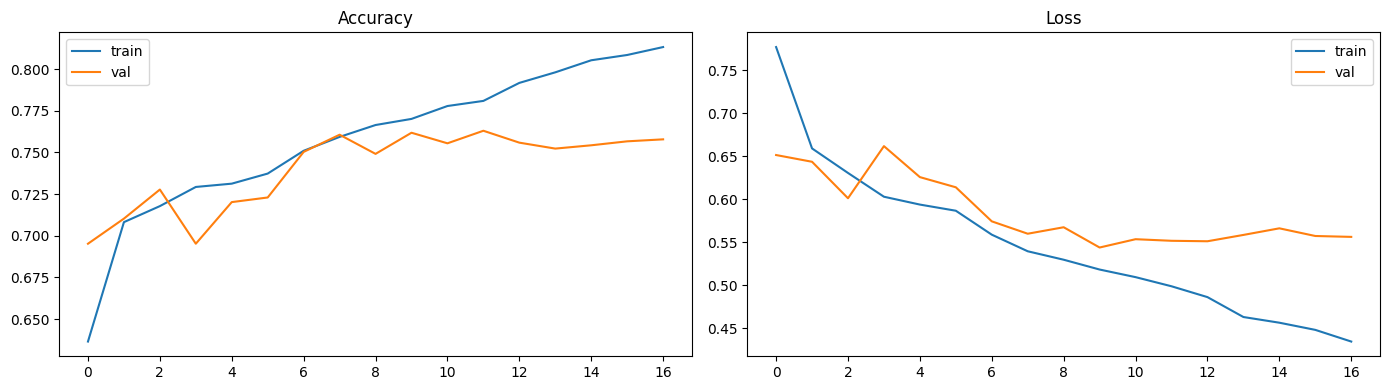

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'],     label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step
              precision    recall  f1-score   support

   Authentic       0.90      0.86      0.88      1498
   Copy-Move       0.57      0.73      0.64       660
    Splicing       0.61      0.44      0.51       365

    accuracy                           0.76      2523
   macro avg       0.70      0.67      0.68      2523
weighted avg       0.77      0.76      0.76      2523



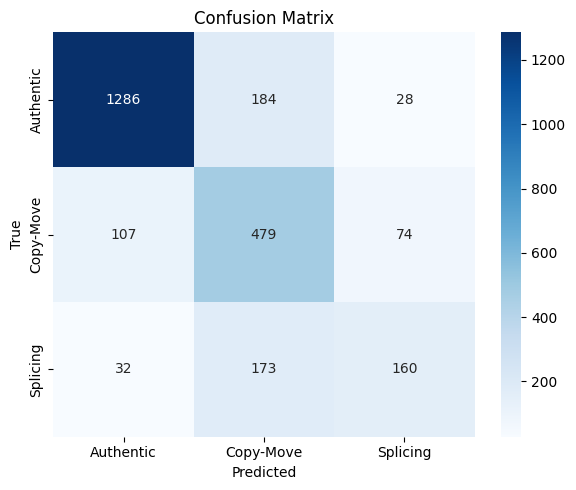

In [19]:
CLASS_NAMES = ['Authentic', 'Copy-Move', 'Splicing']

Y_pred_prob = model.predict({'ela_input': X_ela_val, 'akaze_input': X_ak_val})
Y_pred      = np.argmax(Y_pred_prob, axis=1)
Y_true      = np.argmax(Y_val, axis=1)

print(classification_report(Y_true, Y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()

In [20]:
def predict_image(path):
    ela  = ela_array(path)[np.newaxis, ...]
    akaz = akaze_copy_move_score(path)[np.newaxis, ...]
    prob = model.predict({'ela_input': ela, 'akaze_input': akaz}, verbose=0)[0]
    pred = int(np.argmax(prob))
    print(f"{Path(path).name}")
    for name, p in zip(CLASS_NAMES, prob):
        bar = '█' * int(p * 30)
        print(f"  {name:<12} {bar:<30} {p:.3f}")
    print(f"  → Prediction: {CLASS_NAMES[pred]}")

predict_image('Au_ani_00019.jpg')
predict_image('Tp_D_CNN_M_N_pla00042_pla00042_10976.jpg')
predict_image('Tp_D_NRN_S_N_nat10161_cha00063_12080.jpg')

Au_ani_00019.jpg
  Authentic    █████████████████              0.583
  Copy-Move    ███████                        0.250
  Splicing     █████                          0.167
  → Prediction: Authentic
Tp_D_CNN_M_N_pla00042_pla00042_10976.jpg
  Authentic    ███                            0.129
  Copy-Move    ████████████                   0.415
  Splicing     █████████████                  0.457
  → Prediction: Splicing
Tp_D_NRN_S_N_nat10161_cha00063_12080.jpg
  Authentic    ██                             0.079
  Copy-Move    ██████████████████             0.624
  Splicing     ████████                       0.297
  → Prediction: Copy-Move


In [ ]:
model.save('casia2_ela_akaze_fusion.keras')
print("Model saved.")

Model saved.
